# Movies Visualization
### Carlos Muñiz Lara

In [1]:
from spark_utils import SparkUtils
su = SparkUtils()
su

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/10 00:59:58 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


<SparkContext master=spark://spark-master:7077 appName=helloworld>

In [2]:
column_types = [
    ("MovieID", "int"),
    ("Title", "string"),
    ("Genre", "string"),
    ("ReleaseYear", "int"),
    ("ReleaseDate_Str", "string"),
    ("Country", "string"),
    ("BudgetUSD", "float"),
    ("US_BoxOfficeUSD", "float"),
    ("Global_BoxOfficeUSD", "float"),
    ("Opening_Day_SalesUSD", "float"),
    ("One_Week_SalesUSD", "float"),
    ("IMDbRating", "float"),
    ("RottenTomatoesScore", "float"),
    ("NumVotesIMDb", "int"),
    ("NumVotesRT", "int"),
    ("Director", "string"),
    ("LeadActor", "string")
]

movies_schema = SparkUtils.generate_schema(column_types)
qcommerce_df = su._spark \
                .read \
                .option("header", "true") \
                .schema(movies_schema) \
                .csv("/opt/spark/work-dir/data/movies/")

In [3]:
qcommerce_df.show(5)

+-------+--------------------+-----------+-----------+---------------+-------+---------+---------------+-------------------+--------------------+-----------------+----------+-------------------+------------+----------+---------------+------------------+
|MovieID|               Title|      Genre|ReleaseYear|ReleaseDate_Str|Country|BudgetUSD|US_BoxOfficeUSD|Global_BoxOfficeUSD|Opening_Day_SalesUSD|One_Week_SalesUSD|IMDbRating|RottenTomatoesScore|NumVotesIMDb|NumVotesRT|       Director|         LeadActor|
+-------+--------------------+-----------+-----------+---------------+-------+---------+---------------+-------------------+--------------------+-----------------+----------+-------------------+------------+----------+---------------+------------------+
|      1|Might toward capital|     Comedy|       2003|     28-09-2003|  China|6577428.0|      6613686.0|        1.5472036E7|           1778530.9|        3034053.2|       6.2|               58.0|        7865|     10596| Kristina Moore|   B

In [4]:
from pyspark.sql.functions import to_date
movies_df = qcommerce_df.withColumn("ReleaseDate", to_date("ReleaseDate_Str", "dd-MM-yyyy")).drop("ReleaseDate_Str")
movies_df.show(5)

+-------+--------------------+-----------+-----------+-------+---------+---------------+-------------------+--------------------+-----------------+----------+-------------------+------------+----------+---------------+------------------+-----------+
|MovieID|               Title|      Genre|ReleaseYear|Country|BudgetUSD|US_BoxOfficeUSD|Global_BoxOfficeUSD|Opening_Day_SalesUSD|One_Week_SalesUSD|IMDbRating|RottenTomatoesScore|NumVotesIMDb|NumVotesRT|       Director|         LeadActor|ReleaseDate|
+-------+--------------------+-----------+-----------+-------+---------+---------------+-------------------+--------------------+-----------------+----------+-------------------+------------+----------+---------------+------------------+-----------+
|      1|Might toward capital|     Comedy|       2003|  China|6577428.0|      6613686.0|        1.5472036E7|           1778530.9|        3034053.2|       6.2|               58.0|        7865|     10596| Kristina Moore|   Brian Mccormick| 2003-09-28|


In [5]:
!pip install matplotlib
!pip install pandas

In [6]:
import matplotlib.pyplot as plt

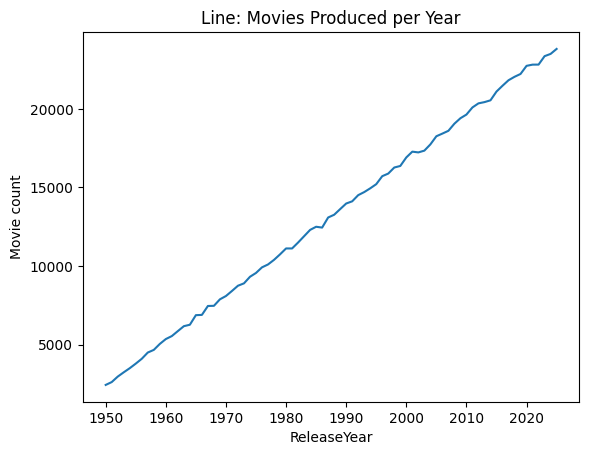

In [7]:
sdf = (movies_df
       .groupBy("ReleaseYear")
       .count()
       .orderBy("ReleaseYear"))

pdf = sdf.toPandas()

plt.figure()
plt.plot(pdf["ReleaseYear"], pdf["count"])
plt.title("Line: Movies Produced per Year")
plt.xlabel("ReleaseYear")
plt.ylabel("Movie count")
plt.show()

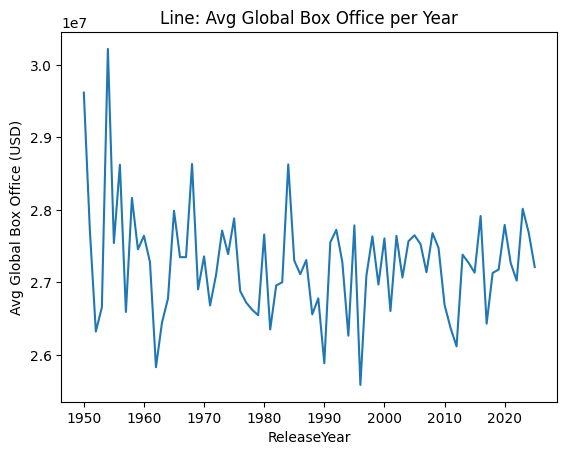

In [8]:
from pyspark.sql import functions as F
sdf = (movies_df
       .groupBy("ReleaseYear")
       .agg(F.avg("Global_BoxOfficeUSD").alias("avg_global"))
       .orderBy("ReleaseYear"))

pdf = sdf.toPandas()

plt.figure()
plt.plot(pdf["ReleaseYear"], pdf["avg_global"])
plt.title("Line: Avg Global Box Office per Year")
plt.xlabel("ReleaseYear")
plt.ylabel("Avg Global Box Office (USD)")
plt.show()

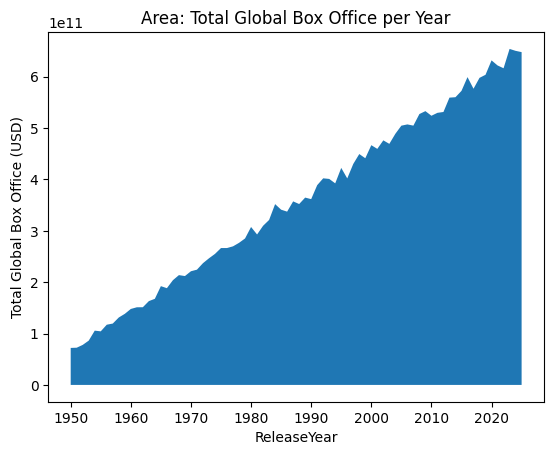

In [9]:
sdf = (movies_df
       .groupBy("ReleaseYear")
       .agg(F.sum("Global_BoxOfficeUSD").alias("sum_global"))
       .orderBy("ReleaseYear"))

pdf = sdf.toPandas()

plt.figure()
plt.fill_between(pdf["ReleaseYear"], pdf["sum_global"])
plt.title("Area: Total Global Box Office per Year")
plt.xlabel("ReleaseYear")
plt.ylabel("Total Global Box Office (USD)")
plt.show()

## Question 1: Wich genre dominates the dataset?

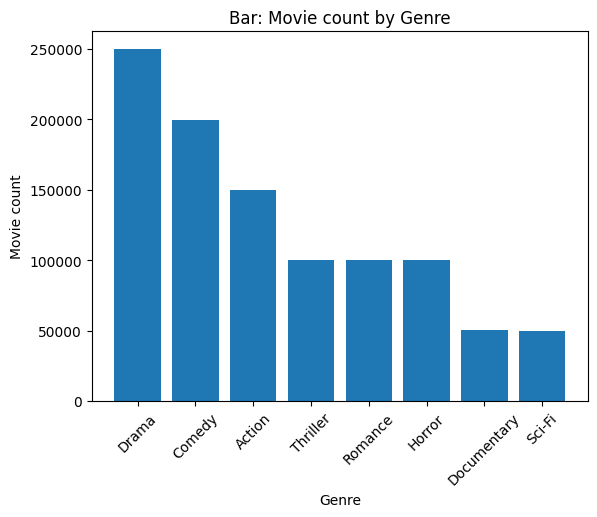

In [10]:
question1 = (movies_df.groupBy("Genre").count().orderBy("count", ascending=False))
pandasq1 = question1.toPandas()
plt.figure()
plt.bar(pandasq1["Genre"], pandasq1["count"])
plt.title("Bar: Movie count by Genre")
plt.xlabel("Genre")
plt.ylabel("Movie count")
plt.xticks(rotation=45)
plt.show()

## Question 2: Wich countries produce the most successful films?

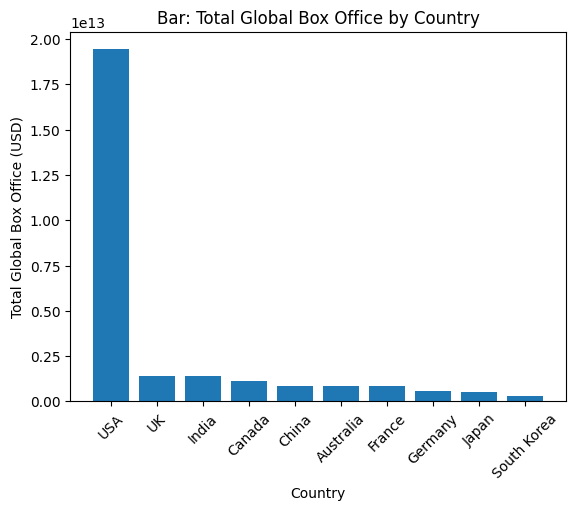

In [12]:
question2 = (movies_df.groupBy("Country").agg(F.sum("Global_BoxOfficeUSD").alias("total_global")).orderBy("total_global", ascending=False)) 
pandasq2 = question2.toPandas()
plt.figure()
plt.bar(pandasq2["Country"], pandasq2["total_global"])
plt.title("Bar: Total Global Box Office by Country")
plt.xlabel("Country")
plt.ylabel("Total Global Box Office (USD)")
plt.xticks(rotation=45)
plt.show()

## Wich directores produce the highest rated movies after 2010?

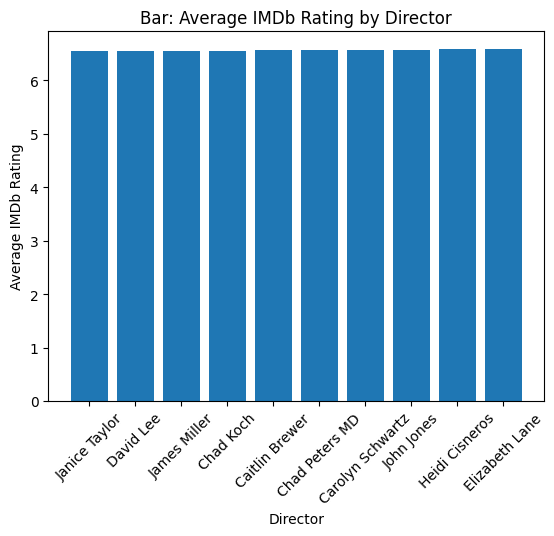

In [ ]:
question3 = (movies_df.filter(F.col("ReleaseYear")>2010).groupBy("Director").agg(F.avg("IMDbRating").alias("avg_rating")).orderBy("avg_rating", ascending=False).limit(10))
pandasq3 = question3.toPandas()
plt.figure()
plt.bar(pandasq3["Director"], pandasq3["avg_rating"])
plt.title("Bar: Average IMDb Rating by Director")
plt.xlabel("Director")
plt.ylabel("Average IMDb Rating")
plt.xticks(rotation=45)
plt.show()

In [20]:
su._spark.stop()